In [1]:
import numpy as np

fname = "Lx_24_Nd_500_NT_34560_px_0.0_MPI_hexagonal6.npz"

# npzファイルを開く
data = np.load(fname)

# キー一覧を表示
print("keys:", data.files)

# 各キーの shape や dtype を確認
for k in data.files:
    arr = data[k]
    print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

# 例えば pg をちょっと見る
print("pg[:10] =", data["pg"][:10])


keys: ['pg', 'TEE1_ave', 'TEE1_err', 'TEE1_var', 'TEE2_ave', 'TEE2_err', 'TEE2_var', 'TEE3_ave', 'TEE3_err', 'TEE3_var', 'TEE4_ave', 'TEE4_err', 'TEE4_var', 'TEE5_ave', 'TEE5_err', 'TEE5_var', 'TEE6_ave', 'TEE6_err', 'TEE6_var']
pg: shape=(42,), dtype=float64
TEE1_ave: shape=(42,), dtype=float64
TEE1_err: shape=(42,), dtype=float64
TEE1_var: shape=(42,), dtype=float64
TEE2_ave: shape=(42,), dtype=float64
TEE2_err: shape=(42,), dtype=float64
TEE2_var: shape=(42,), dtype=float64
TEE3_ave: shape=(42,), dtype=float64
TEE3_err: shape=(42,), dtype=float64
TEE3_var: shape=(42,), dtype=float64
TEE4_ave: shape=(42,), dtype=float64
TEE4_err: shape=(42,), dtype=float64
TEE4_var: shape=(42,), dtype=float64
TEE5_ave: shape=(42,), dtype=float64
TEE5_err: shape=(42,), dtype=float64
TEE5_var: shape=(42,), dtype=float64
TEE6_ave: shape=(42,), dtype=float64
TEE6_err: shape=(42,), dtype=float64
TEE6_var: shape=(42,), dtype=float64
pg[:10] = [0.7   0.705 0.71  0.715 0.72  0.725 0.73  0.735 0.74  0.745]


In [4]:
import numpy as np
from collections import defaultdict
import re, math
from pathlib import Path

# ===== 0) 入力ログを列挙 =====
logs = [
    "slurm-2673486.out",
    "slurm-2677278.out",   # ← もう一つのファイル名に置き換えて
]

# ===== 1) ログをパースして {pg: list of [TEE1..TEE6]} を作る（複数ファイル統合） =====
bucket = defaultdict(list)
pat = re.compile(
    r"pg=\s*([0-9.]+).*?"
    r"TEE1=\s*([-0-9.]+).*?TEE2=\s*([-0-9.]+).*?"
    r"TEE3=\s*([-0-9.]+).*?TEE4=\s*([-0-9.]+).*?"
    r"TEE5=\s*([-0-9.]+).*?TEE6=\s*([-0-9.]+)"
)

for log in logs:
    with open(log) as f:
        for line in f:
            m = pat.search(line)
            if m:
                pg = float(m.group(1))
                tees = list(map(float, m.groups()[1:]))  # 6要素
                bucket[pg].append(tees)

if not bucket:
    raise RuntimeError("ログからデータが見つかりませんでした。正規表現やファイル名を確認してください。")

# ===== 2) ソートしてスタック配列化 =====
pg = np.array(sorted(bucket.keys()), dtype=float)              # (nP,)
# 各 pg でサンプル数が異なる可能性があるので、あとで個別に処理する
stacks = {p: np.asarray(bucket[p], dtype=float) for p in pg}   # dict[pg] -> (nSamples, 6)

# ===== 3) 分散とそのブートストラップ標準誤差 =====
def bootstrap_var(x, nboot=1000, rng=np.random.default_rng(0)):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n <= 3:
        return np.var(x, ddof=1) if n>1 else np.nan, np.nan
    vs = np.empty(nboot, dtype=float)
    for i in range(nboot):
        idx = rng.integers(0, n, n)
        vs[i] = np.var(x[idx], ddof=1)
    return np.var(x, ddof=1), np.std(vs, ddof=1)

var6  = np.zeros((len(pg), 6), dtype=float)
dvar6 = np.zeros((len(pg), 6), dtype=float)
nsamp = np.zeros((len(pg),), dtype=int)

for i, p in enumerate(pg):
    X = stacks[p]                    # (nSamples, 6)
    nsamp[i] = len(X)
    for k in range(6):
        v, dv = bootstrap_var(X[:, k], nboot=1000)
        var6[i, k]  = v
        dvar6[i, k] = dv

# ===== 4) 保存（pyfssa に渡しやすい鍵名） =====
out = {"pg": pg, "Nsamples": nsamp}
for k in range(6):
    out[f"TEE{k+1}_var"] = var6[:, k]
    out[f"TEE{k+1}_err"] = dvar6[:, k]   # 平均の誤差ではなく「分散」の標準誤差

np.savez_compressed("from_logs_var_boot.npz", **out)

# （任意）簡易レポート
print("Merged pg values and sample counts:")
for p, n in zip(pg, nsamp):
    print(f"  pg={p:.6f}: N={n}")
print("Saved -> from_logs_var_boot.npz")


Merged pg values and sample counts:
  pg=0.700000: N=500
  pg=0.705000: N=500
  pg=0.710000: N=500
  pg=0.715000: N=500
  pg=0.720000: N=500
  pg=0.725000: N=500
  pg=0.730000: N=500
  pg=0.735000: N=500
  pg=0.740000: N=500
  pg=0.745000: N=500
  pg=0.750000: N=500
  pg=0.755000: N=500
  pg=0.760000: N=500
  pg=0.765000: N=500
  pg=0.770000: N=500
  pg=0.775000: N=500
  pg=0.780000: N=500
  pg=0.785000: N=500
  pg=0.790000: N=500
  pg=0.795000: N=500
  pg=0.800000: N=500
  pg=0.805000: N=500
  pg=0.810000: N=500
  pg=0.815000: N=500
  pg=0.820000: N=500
  pg=0.825000: N=500
  pg=0.830000: N=500
  pg=0.835000: N=500
  pg=0.840000: N=500
  pg=0.845000: N=500
  pg=0.850000: N=500
  pg=0.855000: N=500
  pg=0.860000: N=500
  pg=0.865000: N=500
  pg=0.870000: N=500
  pg=0.875000: N=500
  pg=0.880000: N=500
  pg=0.885000: N=500
  pg=0.890000: N=500
  pg=0.895000: N=500
  pg=0.900000: N=500
  pg=0.905000: N=500
Saved -> from_logs_var_boot.npz


In [5]:
import numpy as np

fname = "from_logs_var_boot.npz"

# npzファイルを開く
data = np.load(fname)

# キー一覧を表示
print("keys:", data.files)

# 各キーの shape や dtype を確認
for k in data.files:
    arr = data[k]
    print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

# 例えば pg をちょっと見る
print("pg =", data["pg"][:21])
print("TEE1_var =", data["TEE1_var"][:21])
print("TEE1_err =", data["TEE1_err"][:21])
print("TEE2_var =", data["TEE2_var"][:21])
print("TEE2_err =", data["TEE2_err"][:21])
print("TEE3_var =", data["TEE3_var"][:21])
print("TEE3_err =", data["TEE3_err"][:21])
print("TEE4_var =", data["TEE4_var"][:21])
print("TEE4_err =", data["TEE4_err"][:21])

keys: ['pg', 'Nsamples', 'TEE1_var', 'TEE1_err', 'TEE2_var', 'TEE2_err', 'TEE3_var', 'TEE3_err', 'TEE4_var', 'TEE4_err', 'TEE5_var', 'TEE5_err', 'TEE6_var', 'TEE6_err']
pg: shape=(42,), dtype=float64
Nsamples: shape=(42,), dtype=int64
TEE1_var: shape=(42,), dtype=float64
TEE1_err: shape=(42,), dtype=float64
TEE2_var: shape=(42,), dtype=float64
TEE2_err: shape=(42,), dtype=float64
TEE3_var: shape=(42,), dtype=float64
TEE3_err: shape=(42,), dtype=float64
TEE4_var: shape=(42,), dtype=float64
TEE4_err: shape=(42,), dtype=float64
TEE5_var: shape=(42,), dtype=float64
TEE5_err: shape=(42,), dtype=float64
TEE6_var: shape=(42,), dtype=float64
TEE6_err: shape=(42,), dtype=float64
pg = [0.7   0.705 0.71  0.715 0.72  0.725 0.73  0.735 0.74  0.745 0.75  0.755
 0.76  0.765 0.77  0.775 0.78  0.785 0.79  0.795 0.8  ]
TEE1_var = [0.00104604 0.00104397 0.0012893  0.00143587 0.00142866 0.00153047
 0.00185569 0.00228813 0.00223706 0.00238464 0.00258278 0.00288638
 0.00342475 0.00367122 0.00352562 0.003705

In [6]:
import numpy as np

# ===== 入力 =====
AVE_NPZ = "Lx_24_Nd_500_NT_34560_px_0.0_MPI_hexagonal6.npz"   # 例: 'pg', 'TEE{i}_ave', 'TEE{i}_ave_err' を含む
VAR_NPZ = "from_logs_var_boot.npz"   # 例: 'pg', 'TEE{i}_var', 'TEE{i}_err'     を含む
OUT_NPZ = "TEE_merged.npz"

# あなたが指定するサイズ（数値）。例：TEE2=√12, TEE3=√18 など
SIZE = {
    "TEE1": np.sqrt(6),
    "TEE2": np.sqrt(12),
    "TEE3": np.sqrt(18),
    "TEE4": np.sqrt(24),   # ←必要な値を入れてください
    "TEE5": np.sqrt(30),
    "TEE6": np.sqrt(36),
}

# ===== マージ処理 =====
za = np.load(AVE_NPZ)
zv = np.load(VAR_NPZ)

pg_a = za["pg"]
pg_v = zv["pg"]
if not np.allclose(pg_a, pg_v):
    raise ValueError("pg が ave と var で一致していません。揃えてから実行してください。")

out = {"pg": pg_a}

for i in range(1, 7):
    key = f"TEE{i}"

    # サイズ（あなた指定の数値を保存）
    if key not in SIZE:
        raise KeyError(f"SIZE に {key} の指定がありません。")
    out[f"{key}_size"] = float(SIZE[key])

    # ave と誤差（誤差が無ければスキップでOK）
    out[f"{key}_ave"] = za[f"{key}_ave"]
    if f"{key}_err" in za:
        out[f"{key}_ave_err"] = za[f"{key}_err"]

    # var と誤差（あなたの形式に合わせて *_err を拾う）
    out[f"{key}_var"] = zv[f"{key}_var"]
    if f"{key}_err" in zv:               # 例：分散のブート誤差を 'TEE{i}_err' で保存している
        out[f"{key}_var_err"] = zv[f"{key}_err"]
    elif f"{key}_err" in zv:         # 別名対応
        out[f"{key}_var_err"] = zv[f"{key}_err"]

# 保存
np.savez_compressed(OUT_NPZ, **out)
print(f"Wrote {OUT_NPZ} with keys:", list(out.keys()))


Wrote TEE_merged.npz with keys: ['pg', 'TEE1_size', 'TEE1_ave', 'TEE1_ave_err', 'TEE1_var', 'TEE1_var_err', 'TEE2_size', 'TEE2_ave', 'TEE2_ave_err', 'TEE2_var', 'TEE2_var_err', 'TEE3_size', 'TEE3_ave', 'TEE3_ave_err', 'TEE3_var', 'TEE3_var_err', 'TEE4_size', 'TEE4_ave', 'TEE4_ave_err', 'TEE4_var', 'TEE4_var_err', 'TEE5_size', 'TEE5_ave', 'TEE5_ave_err', 'TEE5_var', 'TEE5_var_err', 'TEE6_size', 'TEE6_ave', 'TEE6_ave_err', 'TEE6_var', 'TEE6_var_err']


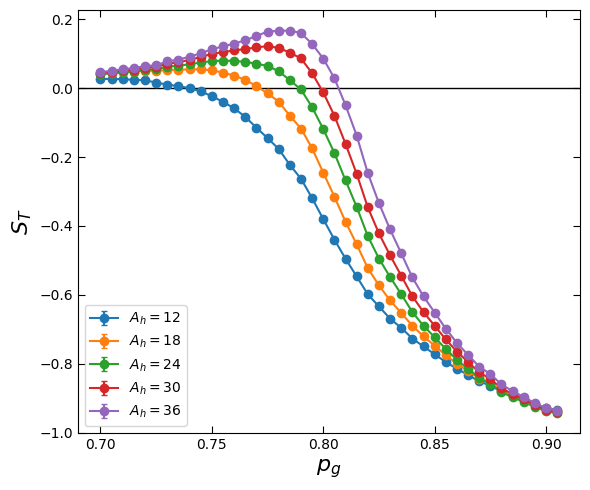

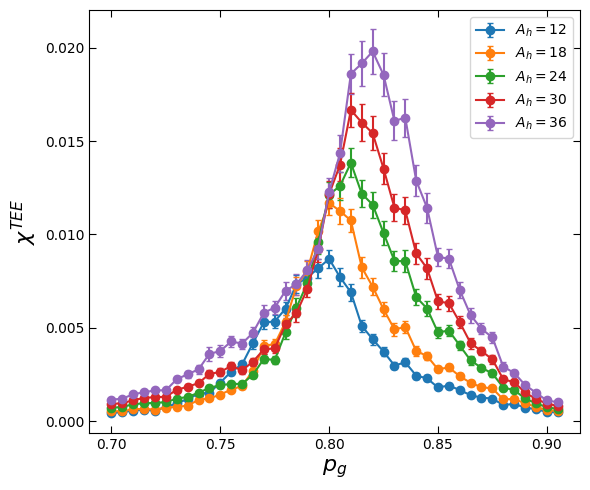

In [7]:
# ave/var を誤差つきで可視化（凡例は *_size）
import numpy as np
import matplotlib.pyplot as plt

NPZ_PATH = "TEE_merged.npz"   # ここをあなたのファイルに
SERIES   = [2, 3, 4, 5, 6] # 描きたい TEE 番号

z  = np.load(NPZ_PATH)
pg = z["pg"].astype(float)

def get(key):  # 存在チェックつき取得
    if key not in z:
        raise KeyError(f"'{key}' が {NPZ_PATH} にありません")
    return z[key].astype(float)


labels = [r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]

# SERIES と labels の対応を作る（順番対応）
if len(labels) < len(SERIES):
    raise ValueError("labels の数が SERIES より少ないです。対応する分だけ用意してください。")
label_map = {s: labels[idx] for idx, s in enumerate(SERIES)}

# --- ave ± err ---
fig, ax = plt.subplots(figsize=(6,5))
for i in SERIES:
    ave    = get(f"TEE{i}_ave")
    aveerr = get(f"TEE{i}_ave_err")
    ax.errorbar(pg, ave, yerr=aveerr, fmt='o-', capsize=2, label=label_map[i])

ax.set_xlabel("$p_g$",fontsize=16)
ax.set_ylabel("$S_{T}$",fontsize=16)
#ax.set_title("Average with error")
ax.legend(title="")

# 目盛りはメジャーのみを内側へ（補助目盛りは使わない）
ax.tick_params(direction='in', which='major', top=True, right=True, length=5)
ax.minorticks_off()  # 補助目盛を完全に無効化
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)
ax.axhline(y=0, color='k', lw=1)
ax.set_ylim(-1)
fig.tight_layout()
fig.savefig("TEE_ave_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


# --- var ± err ---
fig, ax = plt.subplots(figsize=(6,5))
for i in SERIES:
    var    = get(f"TEE{i}_var")
    varerr = get(f"TEE{i}_var_err")
    if len(var) != len(pg) or len(varerr) != len(pg):
        raise ValueError(f"TEE{i} の長さが pg と一致しません")
    ax.errorbar(pg, var, yerr=varerr, fmt='o-', capsize=2, label=label_map[i])
ax.set_xlabel("$p_g$",fontsize=16)
ax.set_ylabel("$\chi^{TEE}$",fontsize=16)


#ax.set_title("Average with error")
ax.legend(title="")

# 目盛りはメジャーのみを内側へ（補助目盛りは使わない）
ax.tick_params(direction='in', which='major', top=True, right=True, length=5)
ax.minorticks_off()  # 補助目盛を完全に無効化
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)

fig.tight_layout()
fig.savefig("TEE_var_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


=== zeta from peak-height scaling (quadratic+bootstrap) ===
mode(L_eff)=sqrtAh, SERIES=['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']
TEE2: L_eff= 3.464 | peak=0.00814375 ± 0.00041 | g*≈0.79563 ± 0.00307
TEE3: L_eff= 4.243 | peak=0.0116735 ± 0.00057 | g*≈0.80510 ± 0.00198
TEE4: L_eff= 4.899 | peak=0.0147934 ± 0.00087 | g*≈0.80952 ± 0.00186
TEE5: L_eff= 5.477 | peak=0.0177146 ± 0.00095 | g*≈0.81310 ± 0.00208
TEE6: L_eff= 6.000 | peak=0.020857 ± 0.001 | g*≈0.81846 ± 0.00308

ζ (MC)   = 1.698642 ± 0.116247
ζ (wOLS) = 1.699997   （参考：重み付きOLSの傾き）


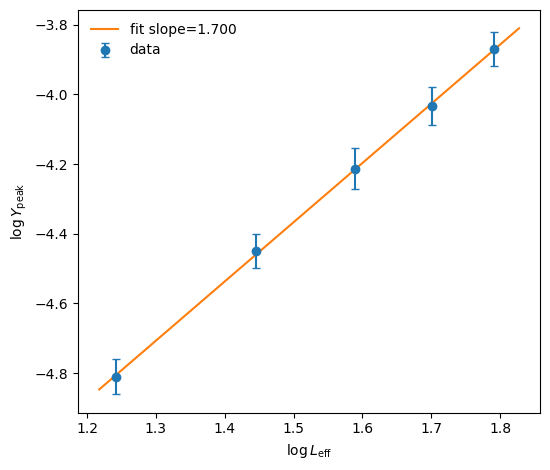

In [28]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt

# ========= 設定 =========
NPZ_PATH = "from_log_var_boot.npz"
SERIES_KEYS = ["TEE2","TEE3","TEE4","TEE5","TEE6"]  # 有効サイズに対応
EFF_SIZE_MODE = "sqrtAh"   # "sqrtAh" or "Ah"
AH_MAP = {"TEE2":12, "TEE3":18, "TEE4":24, "TEE5":30, "TEE6":36}

# --- ピーク抽出 ---
N_BOOT_PEAK = 2000     # 分散曲線→ピーク高さ/位置のブートストラップ
# --- ζ の誤差 ---
N_BOOT_ZETA = 5000     # ピーク高さ±SEからのMC
RNG = np.random.default_rng(0)

# ========= 関数 =========
def eff_size_from_keys(keys, mode="sqrtAh"):
    Ah = np.array([AH_MAP[k] for k in keys], dtype=float)
    return Ah if mode == "Ah" else np.sqrt(Ah)

def quad_vertex(x0, y0, x1, y1, x2, y2):
    """3点 (x0,y0),(x1,y1),(x2,y2) の二次式頂点 (xv, yv)。a≃0 なら中心点にフォールバック。"""
    denom = (x0-x1)*(x0-x2)*(x1-x2)
    if np.isclose(denom, 0.0):
        return x1, y1
    a = (x2*(y1-y0) + x1*(y0-y2) + x0*(y2-y1)) / denom
    b = (x2*x2*(y0-y1) + x1*x1*(y2-y0) + x0*x0*(y1-y2)) / denom
    if np.isclose(a, 0.0):
        return x1, y1
    xv = -b/(2*a)
    # 範囲外に飛んだら中央点
    if not (min(x0,x2) <= xv <= max(x0,x2)):
        xv = x1
    yv = a*xv*xv + b*xv + (y0 - a*x0*x0 - b*x0)  # c を消去して評価
    return xv, yv

def peak_bootstrap_quadratic(g, y, yerr, nboot=1000, rng=None):
    """
    分散曲線 y(g) に誤差を加えてブートストラップ。
    各試行で argmax 近傍の3点に二次フィットし、サブグリッドのピーク高さ/位置を返す。
    端点に最大が来たらグリッド点を採用。
    """
    if rng is None:
        rng = np.random.default_rng()
    yerr = np.maximum(yerr, 1e-16)
    peaks, xpos = [], []
    n = len(g)
    for _ in range(nboot):
        yb = y + rng.normal(0.0, yerr)
        i = int(np.argmax(yb))
        if 0 < i < n-1:
            xv, yv = quad_vertex(g[i-1], yb[i-1], g[i], yb[i], g[i+1], yb[i+1])
            peaks.append(max(yv, 1e-16))
            xpos.append(xv)
        else:
            peaks.append(max(yb[i], 1e-16))
            xpos.append(g[i])
    peaks = np.asarray(peaks)
    xpos  = np.asarray(xpos)
    return peaks.mean(), peaks.std(ddof=1), xpos.mean(), xpos.std(ddof=1)

def zeta_from_loglog_mc(L_eff, Y_mean, Y_se, nboot=5000, rng=None):
    """Y ~ N(Y_mean, Y_se) を再サンプルし、log–log 直線の傾き ζ をブートストラップ。"""
    if rng is None:
        rng = np.random.default_rng()
    x = np.log(L_eff)
    zetas = []
    for _ in range(nboot):
        ys = np.maximum(rng.normal(Y_mean, Y_se), 1e-16)
        y  = np.log(ys)
        # 最小二乗直線（次数1）。重みは Y_se に反映済みとみなす。
        coeff = np.polyfit(x, y, deg=1)
        zetas.append(coeff[0])
    zetas = np.asarray(zetas)
    return zetas.mean(), zetas.std(ddof=1)

def zeta_weighted_ols(L_eff, Y_mean, Y_se):
    """参考：log–log の重み付きOLS（d(logY) ≈ dY/Y を重みとして使用）。"""
    x = np.log(L_eff)
    y = np.log(np.maximum(Y_mean, 1e-16))
    dy = np.maximum(Y_se, 1e-16)/np.maximum(Y_mean, 1e-16)
    w = 1.0/np.square(dy)
    coeff = np.polyfit(x, y, deg=1, w=w)
    return coeff[0]  # slope

# ========= データ読み込み =========
dat = np.load(NPZ_PATH)
g = dat["pg"].astype(float)

# ========= 系列ごとのピーク抽出 =========
peak_means, peak_ses, peak_pos_mean, peak_pos_se = [], [], [], []
for key in SERIES_KEYS:
    if f"{key}_var" not in dat or f"{key}_err" not in dat:
        raise KeyError(f"npz に {key}_var / {key}_err が見つかりません")
    y  = dat[f"{key}_var"].astype(float)
    dy = dat[f"{key}_err"].astype(float)
    # （必要なら臨界窓でマスク）
    g_use, y_use, dy_use = g, y, dy
    mu, se, gx, gs = peak_bootstrap_quadratic(g_use, y_use, dy_use, nboot=N_BOOT_PEAK, rng=RNG)
    peak_means.append(mu); peak_ses.append(se)
    peak_pos_mean.append(gx); peak_pos_se.append(gs)

peak_means    = np.asarray(peak_means)
peak_ses      = np.asarray(peak_ses)
peak_pos_mean = np.asarray(peak_pos_mean)
peak_pos_se   = np.asarray(peak_pos_se)

# ========= 有効サイズ & ζ =========
if len(SERIES_KEYS) < 3:
    raise ValueError("ζ を推定するには少なくとも3サイズ（3系列）が必要です。")

L_eff = eff_size_from_keys(SERIES_KEYS, mode=EFF_SIZE_MODE)

zeta_mean, zeta_std = zeta_from_loglog_mc(L_eff, peak_means, peak_ses,
                                          nboot=N_BOOT_ZETA, rng=RNG)
zeta_wols = zeta_weighted_ols(L_eff, peak_means, peak_ses)  # 参考

# ========= 出力 =========
print("=== zeta from peak-height scaling (quadratic+bootstrap) ===")
print(f"mode(L_eff)={EFF_SIZE_MODE}, SERIES={SERIES_KEYS}")
for k, Le, mu, se, gx, gs in zip(SERIES_KEYS, L_eff, peak_means, peak_ses, peak_pos_mean, peak_pos_se):
    print(f"{k:>4s}: L_eff={Le:>6.3f} | peak={mu:.6g} ± {se:.2g} | g*≈{gx:.5f} ± {gs:.5f}")
print(f"\nζ (MC)   = {zeta_mean:.6f} ± {zeta_std:.6f}")
print(f"ζ (wOLS) = {zeta_wols:.6f}   （参考：重み付きOLSの傾き）")

# ========= 図（log–log） =========
fig, ax = plt.subplots(figsize=(5.6,4.8))
xlog = np.log(L_eff); ylog = np.log(peak_means)
ylog_err = peak_ses/np.maximum(peak_means,1e-16)  # d(logY) ≈ dY/Y
ax.errorbar(xlog, ylog, yerr=ylog_err, fmt='o', capsize=3, label="data")
# 平均値でのフィット線
coef = np.polyfit(xlog, ylog, deg=1)
xx = np.linspace(xlog.min()*0.98, xlog.max()*1.02, 100)
yy = np.polyval(coef, xx)
ax.plot(xx, yy, '-', label=f"fit slope={coef[0]:.3f}")
ax.set_xlabel(r"$\log L_{\rm eff}$")
ax.set_ylabel(r"$\log Y_{\rm peak}$")
ax.legend(frameon=False)
ax.grid(False)
fig.tight_layout()
fig.savefig("zeta_peakheight_loglog.png", dpi=300, bbox_inches="tight")
plt.show()


In [32]:
# ========= ν と pc をピーク位置から推定 =========
from dataclasses import dataclass

@dataclass
class NuPcResult:
    nu_mean: float; nu_std: float
    pc_mean: float; pc_std: float
    a_mean: float;  a_std: float
    chi2_min: float; nu_at_min: float

def fit_pc_a_for_fixed_nu(L_eff, gstar, gse, nu):
    """固定 ν で y = pc + a * L^{-1/nu} を重み付き線形回帰（w=1/σ^2）。"""
    x = L_eff**(-1.0/nu)
    w = 1.0/np.maximum(gse, 1e-16)**2
    # 線形回帰（切片=pc, 傾き=a）
    W = np.sum(w)
    xw = np.sum(w*x)/W
    yw = np.sum(w*gstar)/W
    Swx = np.sum(w*(x-xw)*(gstar-yw))
    Swx2 = np.sum(w*(x-xw)**2)
    a = Swx/Swx2
    pc = yw - a*xw
    # カイ二乗
    yfit = pc + a*x
    chi2 = np.sum(w*(gstar - yfit)**2)
    # 誤差（線形近似の標準公式）
    sigma2 = chi2 / max(len(x)-2, 1)
    pc_se = np.sqrt( sigma2 * (1.0/W + xw**2/Swx2) )
    a_se  = np.sqrt( sigma2 / Swx2 )
    return pc, a, pc_se, a_se, chi2

def estimate_nu_pc_from_peaks(L_eff, gstar_mean, gstar_se,
                              nu_grid=np.linspace(0.9, 3.0, 421),
                              nboot=3000, rng=None):
    """(pc, ν) を推定：nu を粗グリッド走査→各点で pc,a を重み付きOLS→最小χ²を選択。
       その後ブートストラップで (pc,ν,a) の誤差を評価。"""
    if rng is None:
        rng = np.random.default_rng(0)

    # 粗探索
    chi2_list = []; pc_list = []; a_list = []
    for nu in nu_grid:
        pc, a, _, _, chi2 = fit_pc_a_for_fixed_nu(L_eff, gstar_mean, gstar_se, nu)
        chi2_list.append(chi2); pc_list.append(pc); a_list.append(a)
    chi2_arr = np.array(chi2_list); imin = int(np.argmin(chi2_arr))
    nu_best0 = float(nu_grid[imin]); pc_best0 = float(pc_list[imin]); chi2_min = float(chi2_arr[imin])

    # 局所微調整（nu の小範囲で二次近似）
    i0 = max(1, min(imin, len(nu_grid)-2))
    nus_loc = nu_grid[i0-1:i0+2]; chi_loc = chi2_arr[i0-1:i0+2]
    # 二次フィットで最小位置を推定（安全に）
    try:
        coef = np.polyfit(nus_loc, chi_loc, deg=2)
        nu_refined = -coef[1]/(2*coef[0]) if coef[0] > 0 else nu_best0
        nu_refined = float(np.clip(nu_refined, nu_grid[0], nu_grid[-1]))
    except Exception:
        nu_refined = nu_best0

    pc_refined, a_refined, *_ = fit_pc_a_for_fixed_nu(L_eff, gstar_mean, gstar_se, nu_refined)

    # ブートストラップで誤差見積もり
    nu_bs, pc_bs, a_bs = [], [], []
    for _ in range(nboot):
        gs = rng.normal(gstar_mean, gstar_se)
        # 再び nu を粗探索（コスト安のため同じグリッド）
        chi_tmp = []
        for nu in nu_grid:
            _, _, _, _, chi2 = fit_pc_a_for_fixed_nu(L_eff, gs, gstar_se, nu)
            chi_tmp.append(chi2)
        nu0 = float(nu_grid[int(np.argmin(chi_tmp))])
        # 局所二次で微調整
        j = int(np.argmin(chi_tmp))
        j = max(1, min(j, len(nu_grid)-2))
        try:
            c = np.polyfit(nu_grid[j-1:j+2], np.array(chi_tmp)[j-1:j+2], deg=2)
            nu0 = -c[1]/(2*c[0]) if c[0] > 0 else nu0
            nu0 = float(np.clip(nu0, nu_grid[0], nu_grid[-1]))
        except Exception:
            pass
        pc0, a0, *_ = fit_pc_a_for_fixed_nu(L_eff, gs, gstar_se, nu0)
        nu_bs.append(nu0); pc_bs.append(pc0); a_bs.append(a0)

    nu_bs = np.array(nu_bs); pc_bs = np.array(pc_bs); a_bs = np.array(a_bs)
    return NuPcResult(
        nu_mean=float(nu_bs.mean()), nu_std=float(nu_bs.std(ddof=1)),
        pc_mean=float(pc_bs.mean()), pc_std=float(pc_bs.std(ddof=1)),
        a_mean=float(a_bs.mean()),  a_std=float(a_bs.std(ddof=1)),
        chi2_min=chi2_min, nu_at_min=nu_refined
    )

# ===== あなたの既存コードの結果を使って呼び出し =====
# L_eff は既に計算済み：L_eff = eff_size_from_keys(SERIES_KEYS, mode=EFF_SIZE_MODE)
# g* とその誤差は peak_pos_mean / peak_pos_se
nu_grid = np.linspace(0.9, 3.0, 421)  # 必要に応じて変更（例：1.2–2.4など狭める）
res = estimate_nu_pc_from_peaks(L_eff, peak_pos_mean, peak_pos_se,
                                nu_grid=nu_grid, nboot=2000, rng=RNG)

print("\n=== nu from peak-position scaling ===")
print(f"nu   = {res.nu_mean:.6f} ± {res.nu_std:.6f}")
print(f"pc   = {res.pc_mean:.6f} ± {res.pc_std:.6f}")
print(f"a    = {res.a_mean:.6f} ± {res.a_std:.6f}")
print(f"chi2_min (grid) ~ {res.chi2_min:.4g},  nu_at_min ~ {res.nu_at_min:.4f}")



=== nu from peak-position scaling ===
nu   = 2.001079 ± 1.004424
pc   = 0.884065 ± 0.040933
a    = -0.185248 ± 0.031152
chi2_min (grid) ~ 0.541,  nu_at_min ~ 3.0000


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)



=== Variance FSS===
[6.0, 7.3484692283495345, 8.48528137423857, 9.486832980505138, 10.392304845413264]
pc   = 0.873922536 ± 0.003168425
nu   = 1.683839575 ± 0.093374362
zeta = 3.547338248 ± 0.439271832
S     = 2.183722


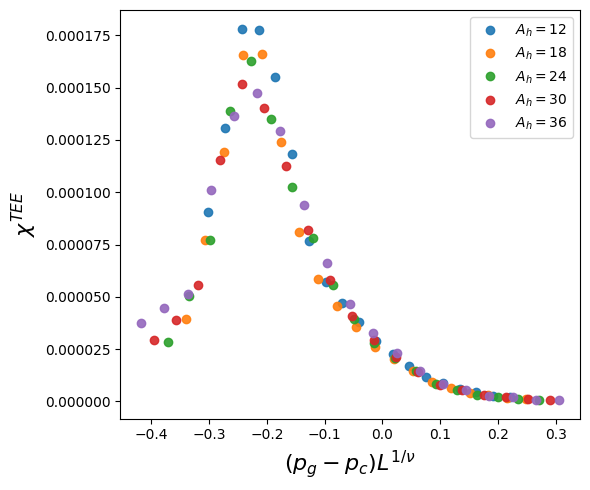

In [31]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力
# ======================
npz_path = "TEE_merged.npz"   # ブートストラップで作ったnpz
# Lは √(セル数) を例として使用（あなたの流儀に合わせて変更）
#L_list   = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
# TEEのどれを使うか（L_listと同数・同順に合わせる）
#TEE_cols = [1,2, 3, 4, 5, 6]  # = TEE2..TEE6 を使う例
TEE_cols = [2, 3, 4, 5, 6]  # = TEE2..TEE6 を使う例

# クリティカル窓（まず少し広め→収束後に狭めるのが吉）
pc_min = 0.77
pc_max = 0.95

# ζを固定すると相関が切れて安定（推奨）
FIX_ZETA = False
ZETA_VAL = 2.9
# ζを自由にしたい場合は False にして下の zeta0 を初期値とする
zeta0    = 2.4


rho_c0, nu0 = 0.87, 1.8


# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（分散とそのSE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

# 例：TEE2..TEE6 を使う
def col_to_key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{col_to_key(c)}_var"] for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{col_to_key(c)}_var_err"] for c in TEE_cols], float)

# --- p窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え（重要） ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# 粗探索で初期値（pc, nu）を作る
# ======================
"""rhos = np.linspace(pg_use.min(), pg_use.max(), 31)
nus  = np.linspace(0.8, 3.0, 30)
bestS, rho_c0, nu0 = np.inf, None, None

for rh in rhos:
    for nv in nus:
        zeta = ZETA_VAL if FIX_ZETA else zeta0
        xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use, rh, nv, zeta)
        S = fssa.quality(xs, ys, dys)
        if S < bestS and np.isfinite(S):
            bestS, rho_c0, nu0 = S, rh, nv

print(f"[coarse] pc0={rho_c0:.6f}, nu0={nu0:.4f}, S={bestS:.4f}")"""

# ======================
# autoscale 本番
# ======================
if FIX_ZETA:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)
    # ζ固定
    ret.zeta  = ZETA_VAL
    ret.dzeta = 0.0
else:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)

# スケール変換（コラプス座標）
xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                             ret.rho, ret.nu, ret.zeta)

# 評価関数
from fssa import quality
S_val = quality(xs, ys, dys)

# ======================
# 結果表示
# ======================
print("\n=== Variance FSS===")
print(L_list)
print(f"pc   = {ret.rho:.9f} ± {getattr(ret, 'drho', np.nan):.9f}")
print(f"nu   = {ret.nu:.9f} ± {getattr(ret, 'dnu',  np.nan):.9f}")
print(f"zeta = {ret.zeta:.9f} ± {getattr(ret, 'dzeta', np.nan):.9f}" + (" (FIXED)" if FIX_ZETA else ""))
print(f"S     = {S_val:.6f}")


# ======================
# プロット（コラプス後）
# ======================
fig, ax = plt.subplots(figsize=(6,5))
labels = [r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]
for i, (L, label) in enumerate(zip(L_list, labels)):
    """ax.errorbar(xs.T[:, i], ys.T[:, i], yerr=dys.T[:, i],
                fmt='o', ms=5, capsize=3, label=label, alpha=0.9)"""
    ax.plot(xs.T[:, i], ys.T[:, i],'o', label=label, alpha=0.9)
ax.set_xlabel(r"$(p_g-p_c)L^{1/\nu}$",fontsize=16)
ax.set_ylabel(r"$\chi^{TEE}$",fontsize=16)
ax.legend( fontsize=10)
ax.grid(False)
fig.tight_layout()
fig.savefig("TEE_collapse_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


In [32]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np, matplotlib.pyplot as plt, warnings
import fssa

NPZ = "TEE_merged.npz"

# ===== 設定 =====
SERIES = [2,3,4,5,6]     # 使う系列（TEE2..TEE6）
FIX_ZETA = True          # まず ζ を固定して安定化
ZETA_VAL = 1.6           # 固定ζの値（1.4〜1.8 で試すのが無難）
ERR_FLOOR_REL = 5e-3     # 誤差フロア（ゼロ重み回避＆数値安定）

# 窓スイープ範囲（中心と半幅）
CENTER_GRID = np.linspace(0.80, 0.88, 41)   # pg の中心候補
HALFW_GRID  = np.linspace(0.01, 0.06, 26)   # 窓半幅候補（→窓幅は 0.02〜0.12）
MIN_POINTS_IN_WINDOW = 6                    # 窓内の p 点数の最低数（各L共通pgなので1回判定でOK）

# ===== データ読み込み =====
dat = np.load(NPZ)
pg  = dat["pg"].astype(float)
order = np.argsort(pg); pg = pg[order]

# L はファイル内の *_size から作る（配列なら平均→ sqrt）
def get_L_from_size(key_prefix):
    s = dat[f"{key_prefix}_size"]
    sval = float(np.mean(s)) if np.ndim(s)>0 else float(s)
    return np.sqrt(sval)

L_list, a_var, da_var = [], [], []
for i in SERIES:
    prefix = f"TEE{i}"
    L_list.append(get_L_from_size(prefix))
    v  = dat[f"{prefix}_var"][order].astype(float)
    dv = dat[f"{prefix}_var_err"][order].astype(float)
    a_var.append(v); da_var.append(dv)
L_list = np.array(L_list, float)
a_var  = np.array(a_var,  float)  # shape=(nL,nP)
da_var = np.array(da_var, float)

# 誤差フロア適用
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var))
da_var = np.maximum(da_var, eps)

# ===== 窓スイープ =====
S_grid = np.full((len(CENTER_GRID), len(HALFW_GRID)), np.nan)
best = {"S": np.inf, "center": None, "halfw": None, "ret": None, "mask": None}

for ic, c in enumerate(CENTER_GRID):
    for iw, w in enumerate(HALFW_GRID):
        pmin, pmax = c - w, c + w
        mask = (pg >= pmin) & (pg <= pmax)
        npts = int(mask.sum())
        if npts < MIN_POINTS_IN_WINDOW:
            continue

        pg_use     = pg[mask]
        a_var_use  = a_var[:,  mask]
        da_var_use = da_var[:, mask]

        # 初期値（中心 c, nu~1.6 を素直に）
        rho_c0, nu0, zeta0 = float(c), 1.6, (ZETA_VAL if FIX_ZETA else 1.6)

        # warnings を握りつつ autoscale
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            try:
                ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                                     rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)
            except Exception:
                continue

        if FIX_ZETA:
            ret.zeta, ret.dzeta = ZETA_VAL, 0.0

        # 質評価 S を計算
        xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                     ret.rho, ret.nu, ret.zeta)
        from fssa import quality
        S = quality(xs, ys, dys)
        if not np.isfinite(S):
            continue

        S_grid[ic, iw] = S
        if S < best["S"]:
            best.update({"S": S, "center": c, "halfw": w, "ret": ret, "mask": mask.copy()})

print(f"[best] S={best['S']:.4f}, center={best['center']:.6f}, halfw={best['halfw']:.6f}")
if best["ret"] is not None:
    print(f"      pc={best['ret'].rho:.6f}, nu={best['ret'].nu:.6f}, zeta={best['ret'].zeta:.6f}{' (FIXED)' if FIX_ZETA else ''}")

# ===== ヒートマップ描画 =====
fig, ax = plt.subplots(figsize=(7,5))
im = ax.pcolormesh(HALFW_GRID, CENTER_GRID, S_grid, shading='auto')
ax.set_xlabel("half-width of window")
ax.set_ylabel("center of window (pg)")
ax.set_title("Window sweep: S (lower is better)")
cb = plt.colorbar(im, ax=ax); cb.set_label("S")
if np.isfinite(best["S"]):
    ax.plot(best["halfw"], best["center"], 'o', ms=8, mfc='none', mec='k', label="best")
    ax.legend()
plt.tight_layout(); plt.savefig("window_sweep_S_heatmap.png", dpi=300, bbox_inches="tight"); plt.show()

# ===== ベスト窓でコラプス図 =====
if best["ret"] is not None:
    mask = best["mask"]
    pg_use     = pg[mask]
    a_var_use  = a_var[:,  mask]
    da_var_use = da_var[:, mask]

    xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                 best["ret"].rho, best["ret"].nu, best["ret"].zeta)

    fig, ax = p


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWa

KeyboardInterrupt: 